<a href="https://colab.research.google.com/github/evkoff/DI-Bootcamp-Stage1/blob/main/Week14/Day4/ExerciseXP/W14D2_XP_Text_Preprocessing%2C_NER%2C_POS%2C_and_Word2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [1]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 98.3 MB/s eta 0:00:00


In [2]:
import nltk
from spacy.cli import download as spacy_download
import spacy

# List of NLTK resources required for this notebook
resources = [
    "punkt",                         # Tokenizer
    "punkt_tab",                     # Tokenizer data
    "wordnet",                       # Lemmatization dictionary
    "omw-1.4",                       # Multilingual WordNet data
    "stopwords",                     # English stopword list
    "averaged_perceptron_tagger",    # POS tagger
    "averaged_perceptron_tagger_eng",# English POS model
    "tagsets",                       # POS tag descriptions
]
# Download all required NLTK resources
for res in resources:
    nltk.download(res, quiet=True)

# Download the small English spaCy model
spacy_download("en_core_web_sm")

# Load the spaCy language model
nlp = spacy.load("en_core_web_sm")

# Show the available NLP pipeline components
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [3]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
# Extract only the list of reviews
raw_reviews = data['Review']

# Display the raw reviews
raw_reviews

["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [10]:
import re                      # Regular expressions (not used in this exercise)
import string                  # Contains punctuation characters
import nltk                    # Main NLTK library

from nltk.corpus import stopwords          # English stopword list
from nltk.stem import WordNetLemmatizer    # Lemmatizer class

# Store English stopwords in a set for fast lookup
stop_words = set(stopwords.words("english"))

# Create a lemmatizer object
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """
    Clean a review by lowercasing, tokenizing,
    removing punctuation and stopwords,
    then lemmatizing the remaining words.
    """

    # Convert text to lowercase
    text = text.lower()

    # Split the text into tokens
    tokens = nltk.word_tokenize(text) # "google loves pizza!" -> ["google", "loves", "pizza", "!"]

    # Remove punctuation tokens
    tokens = [token for token in tokens if token not in string.punctuation]

    # Remove English stopwords
    tokens = [token for token in tokens if token not in stop_words]


    # Convert each token to its lemma
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Join tokens back into a single string
    return " ".join(tokens)

    return tokens

print(preprocess_text(raw_reviews[6]))

terrible experience pizza hut pizza burnt service slow


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [11]:
# TODO: apply preprocess_text to every review and keep both raw and cleaned versions

# Apply preprocessing to every review
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

# Safety check to make sure the dataset was created
if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

# Print raw and cleaned reviews side by side
for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")


RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [14]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""

    # TODO: run the spaCy pipeline on the text
    doc = nlp(text)

    # TODO: collect each entity text and its label_
    return [(ent.text, ent.label_) for ent in doc.ents]

print(perform_ner(raw_reviews[0]))

for review in raw_reviews:
    print(review)
    print(perform_ner(review))
    print("-" * 50)


[('McDonald', 'ORG')]
At McDonald's the food was ok and the service was bad.
[('McDonald', 'ORG')]
--------------------------------------------------
I would not recommend this Japanese restaurant to anyone.
[('Japanese', 'NORP')]
--------------------------------------------------
I loved this restaurant when I traveled to Thailand last summer.
[('Thailand', 'GPE'), ('last summer', 'DATE')]
--------------------------------------------------
The menu of Loving has a wide variety of options.
[('Loving', 'GPE')]
--------------------------------------------------
The staff was friendly and helpful at Google's employees restaurant.
[('Google', 'ORG')]
--------------------------------------------------
The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
[('Bella Italia', 'ORG')]
--------------------------------------------------
I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
[('Pizza Hut', 'ORG')]
----------------------------

### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [15]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""

    # TODO: tokenize the text -  # Split text into tokens
    tokens = word_tokenize(text)

    # TODO: call nltk.pos_tag on the tokens -  # Assign a POS tag to each token
    return pos_tag(tokens)

print(perform_pos_tagging("The pizza was delicious."))


[('The', 'DT'), ('pizza', 'NN'), ('was', 'VBD'), ('delicious', 'JJ'), ('.', '.')]


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [16]:
# Select the first two reviews for comparison
sample_texts = raw_reviews[:2]

# Run NER on raw reviews
print("NER on raw text")
# TODO: loop through sample_texts and print perform_ner results
for text in sample_texts:
    print(perform_ner(text))

# Run NER on cleaned reviews
print("\nNER on cleaned text")
# TODO: repeat using cleaned_reviews
for text in cleaned_reviews[:2]:
    print(perform_ner(text))

# Run POS tagging on raw reviews
print("\nPOS tags on raw text")
# TODO
for text in sample_texts:
    print(perform_pos_tagging(text))

# Run POS tagging on cleaned reviews
print("\nPOS tags on cleaned text")
# TODO
for text in cleaned_reviews[:2]:
    print(perform_pos_tagging(text))

NER on raw text
[('McDonald', 'ORG')]
[('Japanese', 'NORP')]

NER on cleaned text
[("mcdonald 's food ok service", 'ORG')]
[('japanese', 'NORP')]

POS tags on raw text
[('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]
[('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]

POS tags on cleaned text
[('mcdonald', 'NN'), ("'s", 'POS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]
[('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]


## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [25]:
from gensim.models import Word2Vec

# Split each cleaned review into a list of words
tokenized_reviews = [review.split() for review in cleaned_reviews]

# TODO: train the Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1
)

# Display the model
w2v_model


print(w2v_model.wv["pizza"])

[-0.01724867  0.00734439  0.0103754   0.0114805   0.01492502 -0.01234622
  0.00221965  0.01210057 -0.00568245 -0.01234769 -0.00081136 -0.01674063
 -0.01119977  0.01420713  0.00672532  0.01446016  0.0136154   0.01506843
 -0.00758585 -0.00113448  0.00469369 -0.00904397  0.01678702 -0.01971508
  0.01353     0.00583988 -0.00987182  0.00881109 -0.00347277  0.01341815
  0.01992238 -0.00873665 -0.00117672 -0.01138237  0.00771124  0.00556942
  0.01379247  0.01220961  0.01907817  0.01853587  0.01580019 -0.01397029
 -0.01830708 -0.00070261 -0.00621059  0.01576782  0.01189377 -0.00309542
  0.00302022  0.00361078]


In [20]:
print(w2v_model.wv.similarity("pizza", "restaurant"))

0.12694022


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [27]:
# TODO: print the vector size and vocabulary size of your model
# Print the embedding dimension
print("Vector size:", w2v_model.vector_size)
# Print the number of unique words in the vocabulary
print("Vocabulary size:", len(w2v_model.wv))



Vector size: 50
Vocabulary size: 56


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

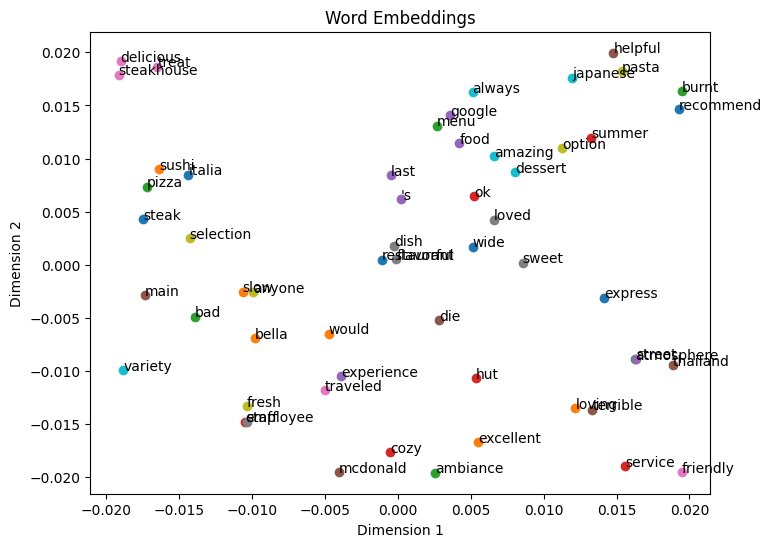

In [28]:

import matplotlib.pyplot as plt

# Plot the first two embedding dimensions
def plot_word_embeddings(model, words=None):

    # Use all words in the vocabulary by default
    if words is None:
        words = model.wv.index_to_key

    # Create a figure
    plt.figure(figsize=(8, 6))

    # Plot each word
    for word in words:

        # Get the embedding vector
        vector = model.wv[word]

        # Use the first two dimensions
        x = vector[0]
        y = vector[1]

        # Draw the point
        plt.scatter(x, y)

        # Label the point with the word
        plt.text(x, y, word)

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title("Word Embeddings")
    plt.show()


# Plot embeddings
plot_word_embeddings(w2v_model)


### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

In [31]:
# Stemming вместо Lemmatization

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed_reviews = []

for review in raw_reviews:
    tokens = nltk.word_tokenize(review.lower())
    tokens = [t for t in tokens if t not in string.punctuation]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    stemmed_reviews.append(" ".join(tokens))

print("Lemmatization:")
print(cleaned_reviews[0])

print("\nStemming:")
print(stemmed_reviews[0])

Lemmatization:
mcdonald 's food ok service bad

Stemming:
mcdonald 's food ok servic bad


In [34]:
# change window size

w2v_window5 = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=50,
    window=5,
    min_count=1,
    sg=1
)

print("Window = 3")
print(w2v_model.wv.most_similar("pizza", topn=5))

print("\nWindow = 6")
print(w2v_window5.wv.most_similar("pizza", topn=5))

Window = 3
[('friendly', 0.2509346008300781), ('helpful', 0.24844062328338623), ('last', 0.1994323581457138), ('fresh', 0.1965344101190567), ('loved', 0.18000151216983795)]

Window = 6
[('friendly', 0.2507381737232208), ('helpful', 0.2483772188425064), ('last', 0.19968575239181519), ('fresh', 0.19609150290489197), ('loved', 0.1800309717655182)]


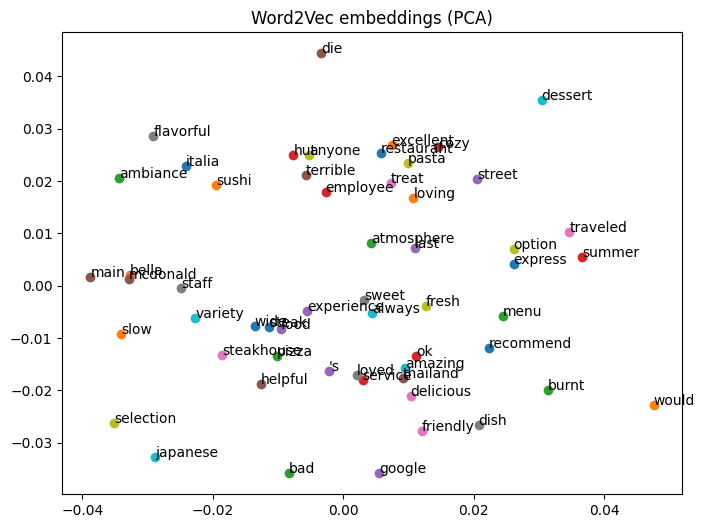

In [33]:
# dimensionality reduction (PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = w2v_model.wv.index_to_key
vectors = [w2v_model.wv[word] for word in words]

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    plt.scatter(vectors_2d[i,0], vectors_2d[i,1])
    plt.annotate(word, (vectors_2d[i,0], vectors_2d[i,1]))

plt.title("Word2Vec embeddings (PCA)")
plt.show()


Stemming produces shortened word forms, while lemmatization keeps valid dictionary words. Lemmatization is generally easier to interpret.

Increasing the context window from 3 to 6 produced almost identical nearest neighbors for the word pizza. Because the dataset contains only a few short sentences, both window sizes capture nearly the same context, so the effect of changing window is minimal.

PCA projects the original 50-dimensional embeddings into two dimensions, making the visualization more meaningful than simply plotting the first two coordinates.